### Plot Velocities
Read and visualize ice velocity grids 

In [ ]:
import numpy as np
import pointAdvection
import pointCollection as pc
import matplotlib.pyplot as plt
import matplotlib.colors as colors


## from me
import xarray as xr

%load_ext autoreload
%autoreload 2

#### File locations

In [1]:
data_dir = '/Volumes/nox3/'

# MOA_file = f'{data_dir}/MOA/moa125_2014_hp1_v01.tif'
# https://nsidc.org/data/NSIDC-0484
vel_file = f'{data_dir}/its_live/antarctica_ice_velocity_450m_v2.nc'

#### Read velocity image and trim to bounds

In [ ]:
# grid bounds to read
#xlimits = (-2470000, -2050000)
#ylimits = (895000, 1325000)
xlimits = (2292425, 2879958)
ylimits = (-627921, -155590)
# read velocity mosaic
# https://nsidc.org/data/NSIDC-0484
a = pointAdvection.advection()
a.filename=vel_file
ds = xr.open_dataset(vel_file).sel(x=slice(*xlimits)).sel(y=slice(*ylimits[::-1]))
a.x, a.y = ds.x.values, ds.y.values
d1 = a.from_nc(filename=vel_file, bounds=[xlimits,ylimits], scale=1.0)
# read MOA image
#m = pc.grid.data().from_geotif(MOA_file, bounds=[xlimits,ylimits])

#### Create plot of velocity with streamlines

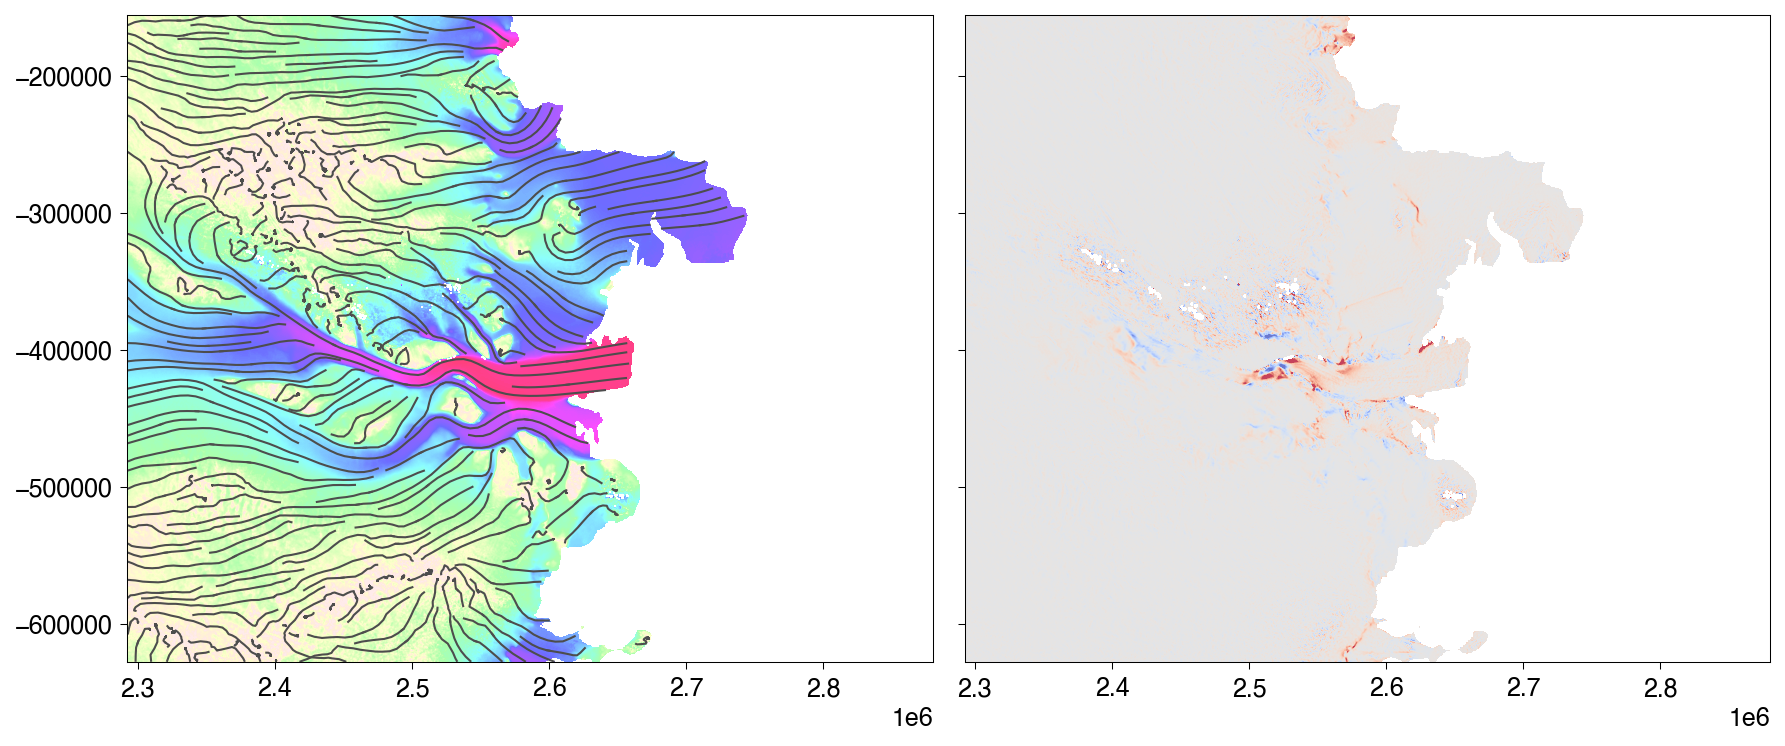

In [68]:
# create output figure axis
fig,ax = plt.subplots(num=1, ncols=2, sharex=True, sharey=True, figsize=(12,6))
# add MODIS mosaic as background
#for axes in ax:
#    m.show(ax=axes, vmin=0, vmax=16386, cmap='gray')
# create color map
cmap = pointAdvection.tools.custom_colormap(180, 'Rignot')
# show velocity magnitude
d1.imshow(ax=ax[0], cmap=cmap, norm=colors.LogNorm(vmin=1, vmax=3000), alpha=0.75)
# show velocity divergence
d1.imshow(ax=ax[1], imtype='divergence', cmap=plt.cm.coolwarm, vmin=-0.1, vmax=0.1, alpha=0.75)
# aspect ratio of input grid
aspect = np.float64(ylimits[1]-ylimits[0])/np.float64(xlimits[1]-xlimits[0])
d1.streamplot(ax=ax[0], density=[3.0,3.0*aspect], arrowstyle='-')
# trim image to limits
ax[0].set_xlim(xlimits)
ax[0].set_ylim(ylimits)
# tight layout
fig.tight_layout()
plt.show()